In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Mengimpor algoritma klasifikasi klasik sesuai ketentuan soal
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Impor Pipeline khusus dari imblearn agar bisa menangani SMOTE di dalam pipeline tanpa leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [14]:
# 1. Membaca dataset survey eksternal
df = pd.read_excel('ANONIM_Survei Preferensi Belajar, Kebiasaan Belajar, dan Faktor Akademik Mahasiswa (Responses).xlsx')

# 2. Menampilkan contoh isi data
print("--- TIGA BARIS PERTAMA DATASET ---")
display(df.head(3))

# 3. Menampilkan info struktur kolom data
print("\n--- INFO STRUKTUR KOLOM ---")
df.info()

# 4. Menampilkan statistik deskriptif data
print("\n--- STATISTIK DESKRIPTIF DATA ---")
display(df.describe(include='all'))

--- TIGA BARIS PERTAMA DATASET ---


,Timestamp,Pernyataan Persetujuan,Program studi,Semester saat ini,Jenis kelamin,Usia (tahun),Status tempat tinggal selama kuliah,Apakah Anda bekerja sambil kuliah?,Sumber pembiayaan utama kuliah saya saat ini adalah:,Rata-rata waktu belajar mandiri per hari di luar jam kuliah,...,"Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir,"Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?","Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E?"
0,2026-03-17 16:11:14.219,Saya BERSEDIA mengikuti survei ini secara suka...,Arsitektur,6,Perempuan,20.0,Kost/asrama,Tidak,"Orang tua / keluarga, Beasiswa sebagian",1–2 jam,...,3.0,3.0,3.0,3.0,4.0,3.0,3.20,2.80,Tidak,Tidak
1,2026-03-17 16:23:55.853,Saya BERSEDIA mengikuti survei ini secara suka...,informatika,6,Perempuan,21.0,Bersama orang tua,Tidak,"Orang tua / keluarga, Beasiswa penuh",2–3 jam,...,3.0,3.0,3.0,2.0,3.0,4.0,3.07,3.91,Tidak,Tidak
2,2026-03-17 16:31:47.507,Saya BERSEDIA mengikuti survei ini secara suka...,Informatika,6,Laki-laki,20.0,Bersama orang tua,Tidak,Orang tua / keluarga,Kurang dari 1 jam,...,4.0,4.0,3.0,4.0,4.0,4.0,3.51,3.51,Tidak,Tidak



--- INFO STRUKTUR KOLOM ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 89 columns):
 #   Column                                                                                                                         Non-Null Count  Dtype         
---  ------                                                                                                                         --------------  -----         
 0   Timestamp                                                                                                                      324 non-null    datetime64[ns]
 1   Pernyataan Persetujuan                                                                                                         324 non-null    object        
 2    Program studi                                                                                                                 323 non-null    object        
 3    Semester saat ini                            

,Timestamp,Pernyataan Persetujuan,Program studi,Semester saat ini,Jenis kelamin,Usia (tahun),Status tempat tinggal selama kuliah,Apakah Anda bekerja sambil kuliah?,Sumber pembiayaan utama kuliah saya saat ini adalah:,Rata-rata waktu belajar mandiri per hari di luar jam kuliah,...,"Saat belajar di rumah, saya mengerjakan latihan soal, tugas, atau kuis untuk memahami materi.","Saat belajar sendiri, saya mencoba langsung langkah-langkah atau prosedur yang sedang dipelajari.","Saat mempelajari materi, saya menggunakan contoh kasus nyata agar lebih mudah memahami konsep.","Saat belajar di rumah, saya melakukan simulasi, praktik, eksperimen, atau demonstrasi kecil sesuai materi yang dipelajari.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.","Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut. 2",IPK kumulatif saat ini,IPS semester terakhir,"Dalam satu semester terakhir, apakah Anda pernah mengulang mata kuliah?","Dalam satu semester terakhir, apakah Anda pernah mendapat nilai D/E?"
count,324,324,323,323.0,323,323.000000,323,323,323,323,...,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323.000000,323,323
unique,NaN,2,125,8.0,2,NaN,5,3,16,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,Saya BERSEDIA mengikuti survei ini secara suka...,Informatika,6.0,Perempuan,NaN,Kost/asrama,Tidak,Orang tua / keluarga,1–2 jam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tidak,Tidak
freq,NaN,323,72,187.0,182,NaN,198,237,234,132,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283,301
mean,2026-04-21 19:47:46.415814912,NaN,NaN,NaN,NaN,20.931889,NaN,NaN,NaN,NaN,...,3.866873,3.925697,3.993808,3.730650,4.024768,4.049536,10.906935,10.324056,NaN,NaN
min,2026-03-17 16:11:14.219000,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,NaN,NaN
25%,2026-04-14 22:12:47.149500160,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,...,3.000000,3.000000,3.000000,3.000000,3.500000,3.500000,3.365000,3.500000,NaN,NaN
50%,2026-04-25 00:01:07.254500096,NaN,NaN,NaN,NaN,21.000000,NaN,NaN,NaN,NaN,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.600000,3.700000,NaN,NaN
75%,2026-04-28 21:40:19.310249984,NaN,NaN,NaN,NaN,21.000000,NaN,NaN,NaN,NaN,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.800000,3.900000,NaN,NaN
max,2026-05-02 14:11:52.871000,NaN,NaN,NaN,NaN,26.000000,NaN,NaN,NaN,NaN,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,390.000000,380.000000,NaN,NaN


--- PEMERIKSAAN KUALITAS DATA ---
Jumlah baris dengan data kosong per kolom:
 Program studi                                                                                                           1
 Semester saat ini                                                                                                       1
 Jenis kelamin                                                                                                           1
 Usia  (tahun)                                                                                                           1
 Status tempat tinggal selama kuliah                                                                                     1
                                                                                                                        ..
Saat merasa belum paham, saya mencoba sendiri sampai mengetahui cara kerja atau penyelesaian dari materi tersebut.  2    1
  IPK kumulatif saat ini                                      

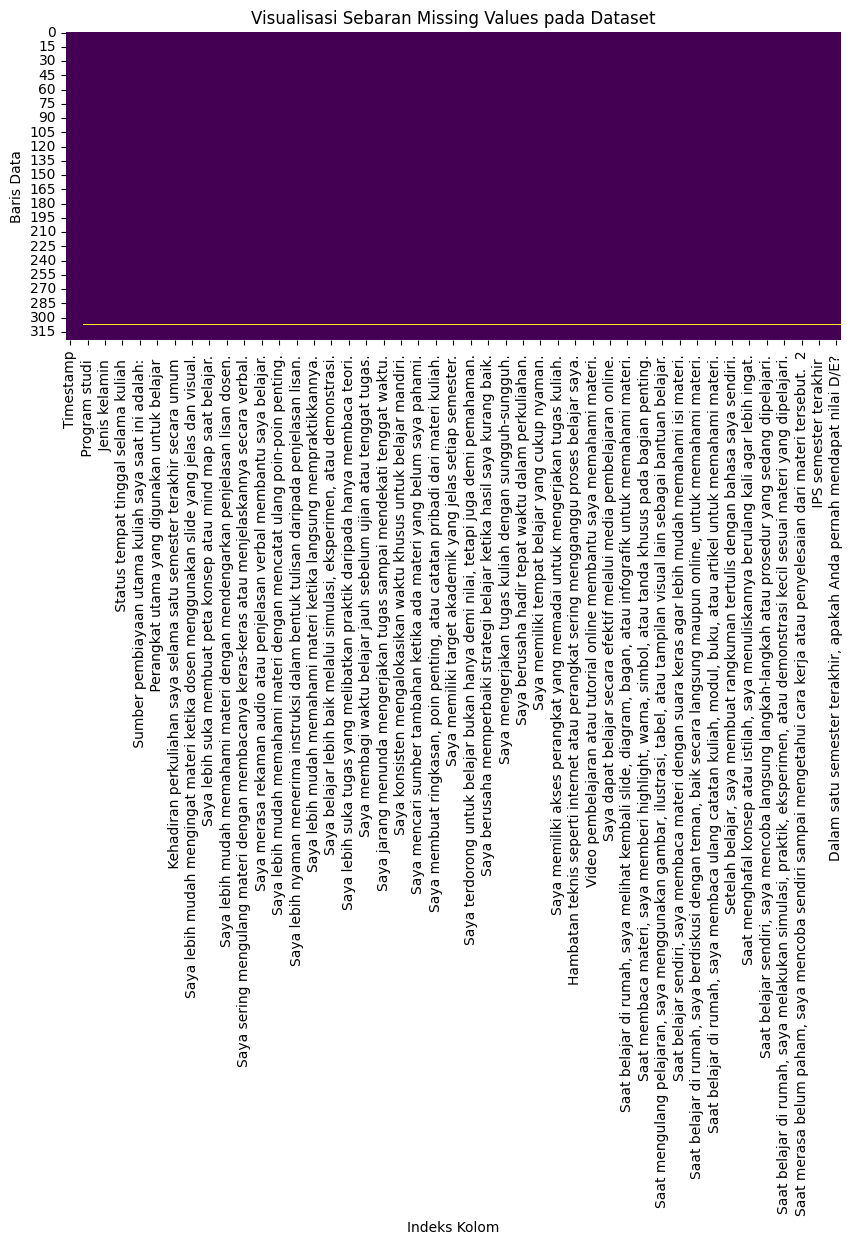

Interpretasi: Grafik heatmap menunjukkan sebaran data kosong. Jika bersih, grafik akan berwarna penuh tanpa garis putus-putus.


In [15]:
print("--- PEMERIKSAAN KUALITAS DATA ---")
# Cek Missing Values
missing_val = df.isnull().sum()
print(f"Jumlah baris dengan data kosong per kolom:\n{missing_val[missing_val > 0]}\n")

# Cek Duplikasi Data
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

# Visualisasi ringkasan kualitas data (Missing Value)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Visualisasi Sebaran Missing Values pada Dataset")
plt.xlabel("Indeks Kolom")
plt.ylabel("Baris Data")
plt.show()
print("Interpretasi: Grafik heatmap menunjukkan sebaran data kosong. Jika bersih, grafik akan berwarna penuh tanpa garis putus-putus.")

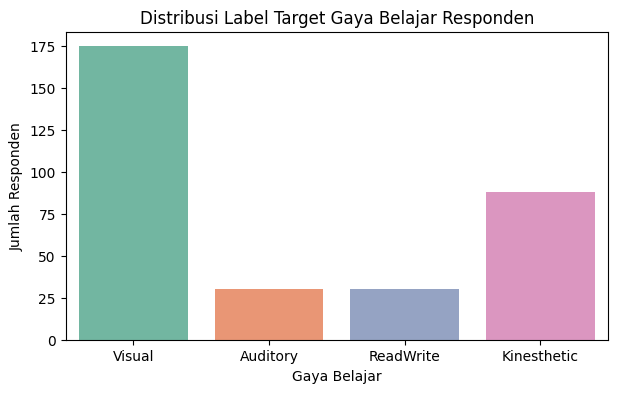

Interpretasi: Grafik menunjukkan sebaran label target gaya belajar, terlihat adanya ketidakseimbangan kelas (class imbalance) yang ekstrem pada kelas Auditory dan ReadWrite.


In [16]:
# 1. Implementasi Anonimitas - Menghapus kolom identitas temporal/personal secara eksplisit
kolom_identitas = ['Timestamp', 'Pernyataan Persetujuan'] # sesuaikan dengan kolom identitas lain jika ada
for kol in kolom_identitas:
    if kol in df.columns:
        df = df.drop(columns=[kol])

# 2. Menangani Data Kosong dengan dropping baris (menghindari manipulasi bias kuesioner)
df = df.dropna()

# 3. Pembentukan Aturan Label Baru (Sesuai Panduan Perhitungan Skor VARK)
kolom_vark = df.columns[10:30] # PASTIKAN INDEKS INI BERADA TEPAT PADA 20 PERTANYAAN VARK ANDA

visual_cols = kolom_vark[0:5]
auditory_cols = kolom_vark[5:10]
readwrite_cols = kolom_vark[10:15]
kinesthetic_cols = kolom_vark[15:20]

df['Score_Visual'] = df[visual_cols].mean(axis=1)
df['Score_Auditory'] = df[auditory_cols].mean(axis=1)
df['Score_ReadWrite'] = df[readwrite_cols].mean(axis=1)
df['Score_Kinesthetic'] = df[kinesthetic_cols].mean(axis=1)

def kalkulasi_vark(row):
    scores = {
        'Visual': row['Score_Visual'],
        'Auditory': row['Score_Auditory'],
        'ReadWrite': row['Score_ReadWrite'],
        'Kinesthetic': row['Score_Kinesthetic']
    }
    return max(scores, key=scores.get)

df['Gaya_Belajar'] = df.apply(kalkulasi_vark, axis=1)

# Visualisasi distribusi kelas target gaya belajar
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Gaya_Belajar', order=['Visual', 'Auditory', 'ReadWrite', 'Kinesthetic'], palette='Set2')
plt.title("Distribusi Label Target Gaya Belajar Responden")
plt.xlabel("Gaya Belajar")
plt.ylabel("Jumlah Responden")
plt.show()
print("Interpretasi: Grafik menunjukkan sebaran label target gaya belajar, terlihat adanya ketidakseimbangan kelas (class imbalance) yang ekstrem pada kelas Auditory dan ReadWrite.")

In [17]:
NPM_TERBESAR_2DIGIT = 80

X = df[list(kolom_vark)].copy()
y = df['Gaya_Belajar']

# Encode target label ke numerik
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Latih-Uji Split secara Stratified untuk mempertahankan distribusi kelas asli
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=NPM_TERBESAR_2DIGIT, stratify=y_encoded
)

print(f"Dimensi Data Latih: {X_train.shape} | Dimensi Data Uji: {X_test.shape}")

Dimensi Data Latih: (258, 20) | Dimensi Data Uji: (65, 20)


In [18]:
# Deklarasi 4 algoritma klasifikasi klasik sesuai ketentuan tugas
algoritma_models = {
    'Random Forest': RandomForestClassifier(random_state=NPM_TERBESAR_2DIGIT),
    'SVM': SVC(random_state=NPM_TERBESAR_2DIGIT),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=NPM_TERBESAR_2DIGIT)
}

baseline_scores = {}

# Evaluasi ke-4 model menggunakan objek Pipeline terisolasi untuk mencegah data leakage
for name, model in algoritma_models.items():
    pipeline_baseline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=NPM_TERBESAR_2DIGIT)), # SMOTE diletakkan dalam pipeline
        ('feature_selection', SelectKBest(score_func=f_classif, k=15)), # Feature Selection awal
        ('classifier', model)
    ])
    
    pipeline_baseline.fit(X_train, y_train)
    y_pred_base = pipeline_baseline.predict(X_test)
    baseline_scores[name] = accuracy_score(y_test, y_pred_base)
    print(f"Akurasi Baseline Pipeline {name}: {baseline_scores[name]:.4f}")

Akurasi Baseline Pipeline Random Forest: 0.5692
Akurasi Baseline Pipeline SVM: 0.5846
Akurasi Baseline Pipeline KNN: 0.4308
Akurasi Baseline Pipeline Decision Tree: 0.4615


In [19]:
# Membuat satu arsitektur master pipeline menggunakan model terbaik (Misal: Random Forest)
master_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=NPM_TERBESAR_2DIGIT)),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', RandomForestClassifier(random_state=NPM_TERBESAR_2DIGIT))
])

# Parameter grid menggabungkan pencarian jumlah fitur terbaik dan hyperparameter model
param_grid = {
    'feature_selection__k': [10, 15, 20],                         # Jumlah fitur terbaik yang diuji
    'classifier__n_estimators': [50, 100, 200],                  # Parameter Random Forest
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

# Pencarian parameter terbaik dengan 5-Fold Cross Validation
grid_search = GridSearchCV(
    master_pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_pipeline_model = grid_search.best_estimator_
print("Kombinasi Hyperparameter & Jumlah Fitur Terbaik:")
print(grid_search.best_params_)

Kombinasi Hyperparameter & Jumlah Fitur Terbaik:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50, 'feature_selection__k': 20}



--- CLASSIFICATION REPORT AKHIR ---
              precision    recall  f1-score   support

    Auditory       0.60      0.50      0.55         6
 Kinesthetic       0.67      0.67      0.67        18
   ReadWrite       0.67      0.33      0.44         6
      Visual       0.74      0.83      0.78        35

    accuracy                           0.71        65
   macro avg       0.67      0.58      0.61        65
weighted avg       0.70      0.71      0.70        65



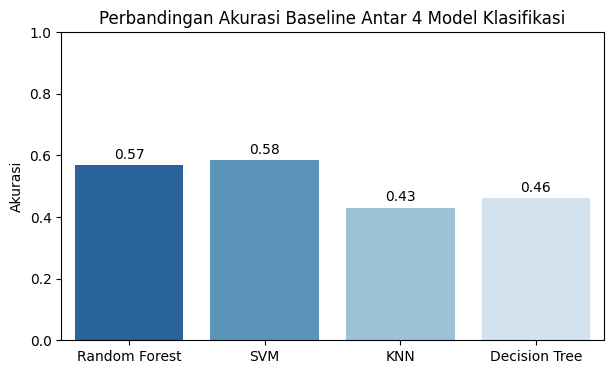

Interpretasi: Grafik barplot membandingkan performa akurasi awal dari keempat model klasifikasi dalam lingkungan pipeline terisolasi.


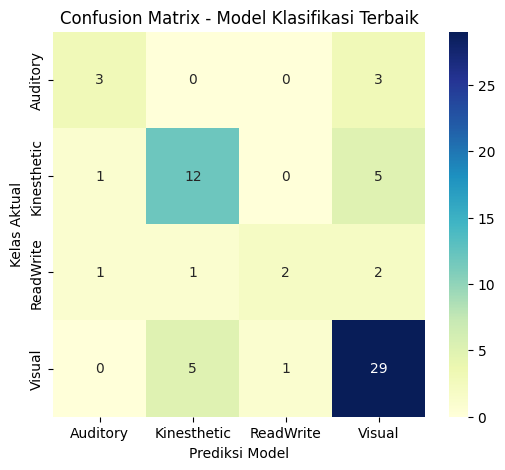

Interpretasi: Heatmap confusion matrix menunjukkan detail klasifikasi benar (diagonal utama) dan kesalahan prediksi model pada setiap kelas gaya belajar.


In [20]:
# Evaluasi performa pada data uji menggunakan model terbaik hasil tuning
y_pred_final = best_pipeline_model.predict(X_test)

print("\n--- CLASSIFICATION REPORT AKHIR ---")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

# 1. Grafik Perbandingan Performa Baseline
plt.figure(figsize=(7, 4))
sns.barplot(x=list(baseline_scores.keys()), y=list(baseline_scores.values()), palette='Blues_r')
plt.title("Perbandingan Akurasi Baseline Antar 4 Model Klasifikasi")
plt.ylabel("Akurasi")
plt.ylim(0, 1.0)
for i, v in enumerate(baseline_scores.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()
print("Interpretasi: Grafik barplot membandingkan performa akurasi awal dari keempat model klasifikasi dalam lingkungan pipeline terisolasi.")

# 2. Matriks Kebingungan (Confusion Matrix) Model Terbaik
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Model Klasifikasi Terbaik")
plt.xlabel("Prediksi Model")
plt.ylabel("Kelas Aktual")
plt.show()
print("Interpretasi: Heatmap confusion matrix menunjukkan detail klasifikasi benar (diagonal utama) dan kesalahan prediksi model pada setiap kelas gaya belajar.")

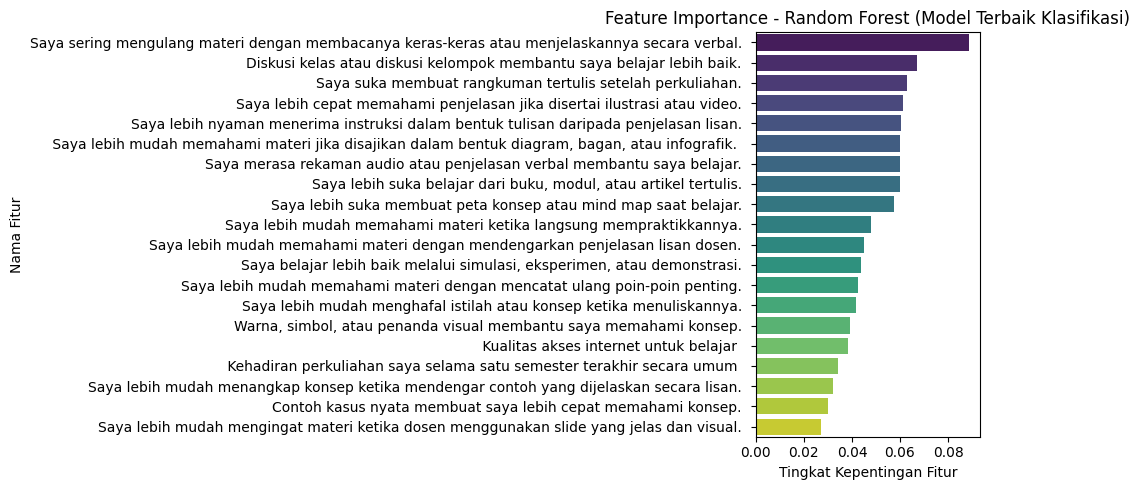

Interpretasi: Grafik menunjukkan fitur mana yang paling berpengaruh dalam memprediksi gaya belajar. Semakin panjang batang, semakin penting fitur tersebut bagi model.


In [21]:
# Feature Importance dari Random Forest
best_rf = best_pipeline_model.named_steps['classifier']
selected_mask = best_pipeline_model.named_steps['feature_selection'].get_support()
selected_features = X.columns[selected_mask]

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=selected_features[indices], palette='viridis')
plt.title("Feature Importance - Random Forest (Model Terbaik Klasifikasi)")
plt.xlabel("Tingkat Kepentingan Fitur")
plt.ylabel("Nama Fitur")
plt.tight_layout()
plt.show()
print("Interpretasi: Grafik menunjukkan fitur mana yang paling berpengaruh dalam memprediksi gaya belajar. Semakin panjang batang, semakin penting fitur tersebut bagi model.")

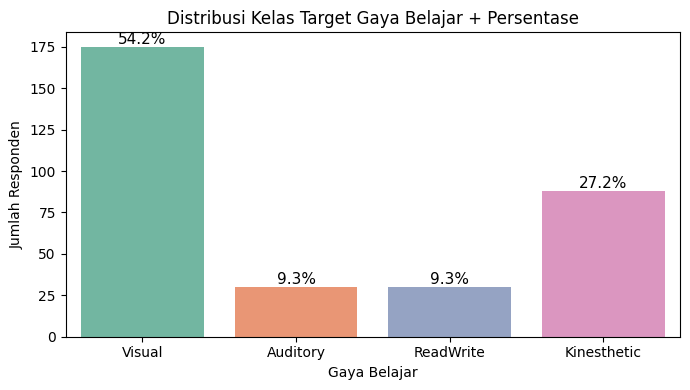

Interpretasi: Grafik menampilkan jumlah dan persentase responden per kelas gaya belajar. Ketimpangan antar kelas (class imbalance) menjadi alasan penggunaan SMOTE dan metrik F1-macro.


In [22]:
#Distribusi Kelas Target dengan Persentase
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Gaya_Belajar', 
                   order=['Visual', 'Auditory', 'ReadWrite', 'Kinesthetic'], 
                   palette='Set2')
total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title("Distribusi Kelas Target Gaya Belajar + Persentase")
plt.xlabel("Gaya Belajar")
plt.ylabel("Jumlah Responden")
plt.tight_layout()
plt.show()
print("Interpretasi: Grafik menampilkan jumlah dan persentase responden per kelas gaya belajar. Ketimpangan antar kelas (class imbalance) menjadi alasan penggunaan SMOTE dan metrik F1-macro.")

In [23]:
import pickle

nama_file_klasifikasi = 'BestModel_Klasifikasi_RandomForest_Kelompok3.pkl'

model_terbaik_klasifikasi = grid_search.best_estimator_ 

with open(nama_file_klasifikasi, 'wb') as file:
    pickle.dump(model_terbaik_klasifikasi, file)

print(f"Berhasil! Model klasifikasi terbaik telah disimpan dengan nama: {nama_file_klasifikasi}")

Berhasil! Model klasifikasi terbaik telah disimpan dengan nama: BestModel_Klasifikasi_RandomForest_Kelompok3.pkl
